# Laboratorio 05 - Naive Bayes para regresion de precio
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

Dataset: `data/listings.RData`

---
## Actividad 1 - Modelo de regresion Naive Bayes para predecir el precio

En scikit-learn no existe un `NaiveBayesRegressor` nativo. Para resolverlo de forma metodologica, se usa un enfoque de dos pasos:
1) discretizar `price_num` en bins (clases) en entrenamiento,
2) entrenar `GaussianNB` para predecir el bin y luego convertir ese bin a un precio numerico usando la mediana del bin.

Para mantener comparabilidad con `../MD-LAB04/main.ipynb`, se replica el mismo preprocesamiento y la misma logica de division (`test_size=0.2`, `random_state=42`, `shuffle=True`, estratificado por deciles de `price_num`).

In [ ]:
# Importaciones base
from pathlib import Path
import numpy as np
import pandas as pd
import pyreadr

# Cargar dataset desde la ruta del laboratorio
rdata_path = Path('data/listings.RData')
result = pyreadr.read_r(str(rdata_path))
df = result['listings'].copy()

print('Objeto cargado:', list(result.keys()))
print('Dimensiones originales:', df.shape)

Objeto cargado: ['listings']
Dimensiones originales: (171748, 80)


### Preprocesamiento y splits (replica de LAB04)

Se mantiene la misma seleccion de variables candidatas, limpieza de `price_num`, recorte al percentil 99, one-hot encoding y division train/test estratificada por deciles. Esto conserva la comparabilidad de resultados entre laboratorios.

In [ ]:
# Utilidad para convertir montos de texto a numerico
def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

# Copia de trabajo para EDA/modelado
df_eda = df.copy()

# Convertir precio a numerico
if 'price' in df_eda.columns:
    df_eda['price_num'] = parse_money(df_eda['price'])

# Convertir porcentajes host a numerico
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_eda.columns:
        df_eda[f'{col}_num'] = pd.to_numeric(
            df_eda[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

# Variables candidatas (mismas de LAB04)
candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df_eda.columns]
model_df = df_eda[selected_cols].copy()

# Limpieza del objetivo y recorte de extremos (mismo criterio LAB04)
model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

# Imputacion de numericas y normalizacion de categoricas
num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

# Matriz de entrada final
X = model_df.drop(columns=['price_num'])
y = model_df['price_num']
X_encoded = pd.get_dummies(X, drop_first=True)

# Split identico a LAB04
from sklearn.model_selection import train_test_split

y_bins_split = pd.qcut(y, q=10, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_bins_split,
)

print('Shape X total:', X_encoded.shape)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)
print('Primeros 5 indices train:', X_train.index[:5].tolist())
print('Primeros 5 indices test:', X_test.index[:5].tolist())

Shape X total: (75531, 520)
X_train: (60424, 520) | X_test: (15107, 520)
y_train: (60424,) | y_test: (15107,)
Primeros 5 indices train: [23421, 36797, 25953, 160615, 27075]
Primeros 5 indices test: [41251, 54191, 163573, 29592, 23803]


### Entrenamiento del modelo Naive Bayes (enfoque para regresion)

Se discretiza `y_train` en 10 bins por cuantiles. Luego `GaussianNB` predice el bin para cada fila de test. Finalmente, cada bin predicho se transforma a valor continuo usando la mediana observada del bin en entrenamiento.

In [ ]:
# Importar modelo y metricas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Discretizar objetivo de entrenamiento en 10 bins por cuantiles
y_bins_train = pd.qcut(y_train, q=10, duplicates='drop')
y_bins_train_str = y_bins_train.astype(str)

# 2) Crear mapeo bin -> mediana de precio (usado para volver a escala continua)
bin_to_median = y_train.groupby(y_bins_train_str).median().to_dict()

# 3) Entrenar GaussianNB
nb_reg_proxy = GaussianNB()
nb_reg_proxy.fit(X_train, y_bins_train_str)

# 4) Predecir bins en test y convertirlos a precio numerico
y_bins_pred = pd.Series(nb_reg_proxy.predict(X_test), index=X_test.index)
y_pred_nb = y_bins_pred.map(bin_to_median).astype(float)

# 5) Baseline sencillo para contexto (siempre predecir mediana de train)
y_pred_baseline = pd.Series(y_train.median(), index=y_test.index)

# 6) Calcular metricas de regresion
mae_nb = mean_absolute_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mean_squared_error(y_test, y_pred_nb))
r2_nb = r2_score(y_test, y_pred_nb)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base = r2_score(y_test, y_pred_baseline)

results = pd.DataFrame([
    {'Modelo': 'Naive Bayes (proxy regresion)', 'MAE': mae_nb, 'RMSE': rmse_nb, 'R2': r2_nb},
    {'Modelo': 'Baseline mediana train', 'MAE': mae_base, 'RMSE': rmse_base, 'R2': r2_base},
]).round(4)

print('Metricas del modelo:')
display(results)

Metricas del modelo:


,Modelo,MAE,RMSE,R2
0,Naive Bayes (proxy regresion),416.7355,896.8748,-0.0841
1,Baseline mediana train,230.1507,875.6788,-0.0334


### Analisis de resultados

Con los resultados obtenidos, el modelo **Naive Bayes (proxy de regresion)** presenta desempeno bajo para este problema: `MAE = 416.74`, `RMSE = 896.87` y `R2 = -0.0841`. Ademas, queda por debajo del baseline de referencia (`MAE = 230.15`, `RMSE = 875.68`, `R2 = -0.0334`).

Un `R2` negativo indica que el modelo explica menos variabilidad que una prediccion constante; por eso, en este experimento no logra capturar adecuadamente la estructura del precio. Esto es consistente con la naturaleza del metodo: se discretiza una variable continua, se asume independencia condicional entre predictores y luego se reconstruye el precio con medianas por bin, lo cual introduce perdida de informacion y errores grandes en valores intermedios/extremos.

**Conclusion de la actividad:** el enfoque es valido como implementacion academica de Naive Bayes para regresion aproximada y cumple la comparabilidad con LAB04 (mismo preprocesamiento y split), pero no es competitivo para prediccion de precio en este dataset. Para mejor desempeno, convienen modelos que capturen no linealidad e interacciones (por ejemplo, arboles, random forest o gradient boosting).

In [ ]:
# Vista rapida de predicciones vs reales para inspeccion
comparison_preview = pd.DataFrame({
    'y_real': y_test.head(15).values,
    'y_pred_nb': y_pred_nb.head(15).values,
})
comparison_preview['error_abs'] = (comparison_preview['y_real'] - comparison_preview['y_pred_nb']).abs()

display(comparison_preview.round(2))

,y_real,y_pred_nb,error_abs
0,344.0,920.0,576.0
1,295.0,920.0,625.0
2,108.0,452.0,344.0
3,69.0,322.0,253.0
4,480.0,322.0,158.0
5,170.0,920.0,750.0
6,80.0,920.0,840.0
7,315.0,209.0,106.0
8,93.0,176.0,83.0
9,200.0,920.0,720.0


---
## Actividad 2 - Evaluacion del modelo Naive Bayes de regresion

En esta actividad se evalua el modelo con metricas correctas de regresion: `MAE`, `RMSE`, `R2`, `MedAE` y `MAPE`.

- `MAE` y `MedAE` miden error absoluto promedio/mediano.
- `RMSE` penaliza mas los errores grandes.
- `R2` mide variabilidad explicada (si es negativo, el modelo rinde peor que una prediccion constante).
- `MAPE` expresa error porcentual promedio respecto al valor real.

In [ ]:
# Importar metricas adicionales para evaluacion de regresion
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error

# Calcular metricas para Naive Bayes (proxy de regresion)
mae_eval = mean_absolute_error(y_test, y_pred_nb)
rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred_nb))
r2_eval = r2_score(y_test, y_pred_nb)
medae_eval = median_absolute_error(y_test, y_pred_nb)
mape_eval = mean_absolute_percentage_error(y_test, y_pred_nb)

# Comparar contra baseline de mediana para dar contexto
mae_base_eval = mean_absolute_error(y_test, y_pred_baseline)
rmse_base_eval = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base_eval = r2_score(y_test, y_pred_baseline)

eval_table = pd.DataFrame([
    {
        'Modelo': 'Naive Bayes (proxy regresion)',
        'MAE': mae_eval,
        'RMSE': rmse_eval,
        'R2': r2_eval,
        'MedAE': medae_eval,
        'MAPE_%': mape_eval * 100,
    },
    {
        'Modelo': 'Baseline mediana train',
        'MAE': mae_base_eval,
        'RMSE': rmse_base_eval,
        'R2': r2_base_eval,
        'MedAE': median_absolute_error(y_test, y_pred_baseline),
        'MAPE_%': mean_absolute_percentage_error(y_test, y_pred_baseline) * 100,
    },
]).round(4)

print('Metricas de regresion - Actividad 2:')
display(eval_table)

# Delta porcentual de error vs baseline (positivo = NB peor en error)
delta_mae_pct = (mae_eval - mae_base_eval) / mae_base_eval * 100
delta_rmse_pct = (rmse_eval - rmse_base_eval) / rmse_base_eval * 100
print(f'Delta MAE vs baseline: {delta_mae_pct:+.2f}%')
print(f'Delta RMSE vs baseline: {delta_rmse_pct:+.2f}%')

Metricas de regresion - Actividad 2:


,Modelo,MAE,RMSE,R2,MedAE,MAPE_%
0,Naive Bayes (proxy regresion),416.7355,896.8748,-0.0841,261.0,196.0260
1,Baseline mediana train,230.1507,875.6788,-0.0334,87.0,69.5991


Delta MAE vs baseline: +81.07%
Delta RMSE vs baseline: +2.42%


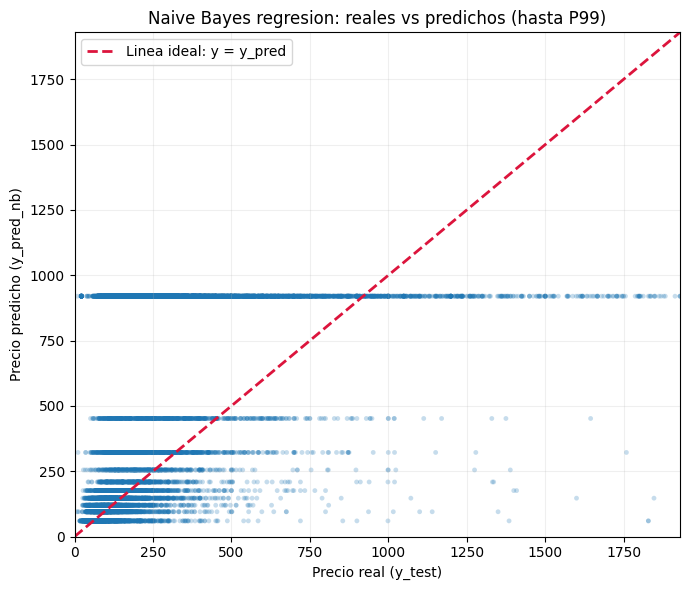

In [ ]:
# Grafica de valores reales vs predichos
import matplotlib.pyplot as plt

# Para mejor lectura visual, se usa limite hasta p99 en ambos ejes
axis_max = np.quantile(np.r_[y_test.values, y_pred_nb.values], 0.99)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_nb, alpha=0.25, s=12, color='#1f77b4', edgecolors='none')
plt.plot([0, axis_max], [0, axis_max], color='crimson', linestyle='--', linewidth=2, label='Linea ideal: y = y_pred')
plt.xlim(0, axis_max)
plt.ylim(0, axis_max)
plt.xlabel('Precio real (y_test)')
plt.ylabel('Precio predicho (y_pred_nb)')
plt.title('Naive Bayes regresion: reales vs predichos (hasta P99)')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Analisis de la Actividad 2

Con la ejecucion actual, el modelo Naive Bayes presenta: `MAE = 416.7355`, `RMSE = 896.8748`, `R2 = -0.0841`, `MedAE = 261.0` y `MAPE = 196.0260%`. Frente al baseline de mediana (`MAE = 230.1507`, `RMSE = 875.6788`, `R2 = -0.0334`), el Naive Bayes queda peor en error absoluto y error cuadratico.

Esto tambien se refleja en los deltas calculados: `+81.07%` en MAE y `+2.42%` en RMSE respecto al baseline. En la grafica de reales vs predichos, muchos puntos quedan lejos de la diagonal ideal `y = y_pred`, mostrando errores altos y predicciones por tramos (efecto de discretizacion en bins).

Conclusion: el enfoque es valido como aproximacion didactica, pero en este dataset no generaliza bien para regresion continua. El `R2` negativo confirma que no supera una referencia simple, por lo que se justifican modelos alternativos para prediccion de precio.

---
## Actividad 3 - Comparacion: Naive Bayes vs Regresion Lineal vs Arbol

Se comparan los tres enfoques con las mismas metricas de regresion usadas en la Actividad 2 (`MAE`, `RMSE`, `R2`, `MedAE`, `MAPE`).

Para mantener consistencia con LAB04, se usa:
- **Regresion lineal base** (pipeline con `StandardScaler` + `LinearRegression`).
- **Arbol de regresion seleccionado por CV en LAB04** (`max_depth=7`).
- **Naive Bayes proxy de regresion** ya entrenado en este notebook.

In [ ]:
# Importar modelos de comparacion
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# 1) Regresion lineal base (mismo enfoque de LAB04)
lin_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
lin_base.fit(X_train, y_train)
y_pred_lin = pd.Series(lin_base.predict(X_test), index=y_test.index)

# 2) Arbol de regresion seleccionado por CV en LAB04 (max_depth=7)
tree_cv7 = DecisionTreeRegressor(max_depth=7, random_state=42)
tree_cv7.fit(X_train, y_train)
y_pred_tree = pd.Series(tree_cv7.predict(X_test), index=y_test.index)

# 3) Funcion auxiliar de metricas (mismas metricas para todos)
def regression_metrics_full(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MedAE': median_absolute_error(y_true, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

# 4) Tabla comparativa final
comparison_models = pd.DataFrame([
    {'Modelo': 'Naive Bayes (proxy regresion)', **regression_metrics_full(y_test, y_pred_nb)},
    {'Modelo': 'Regresion Lineal (base)', **regression_metrics_full(y_test, y_pred_lin)},
    {'Modelo': 'Arbol Regresion (max_depth=7)', **regression_metrics_full(y_test, y_pred_tree)},
]).round(4)

# Ordenar por RMSE (menor es mejor) para lectura rapida
comparison_models = comparison_models.sort_values('RMSE').reset_index(drop=True)

print('Tabla comparativa de modelos (Actividad 3):')
display(comparison_models)

Tabla comparativa de modelos (Actividad 3):


,Modelo,MAE,RMSE,R2,MedAE,MAPE_%
0,Arbol Regresion (max_depth=7),160.0926,487.6944,0.6795,79.1202,68.8909
1,Regresion Lineal (base),252.8459,760.4884,0.2206,128.2635,109.2552
2,Naive Bayes (proxy regresion),416.7355,896.8748,-0.0841,261.0000,196.0260


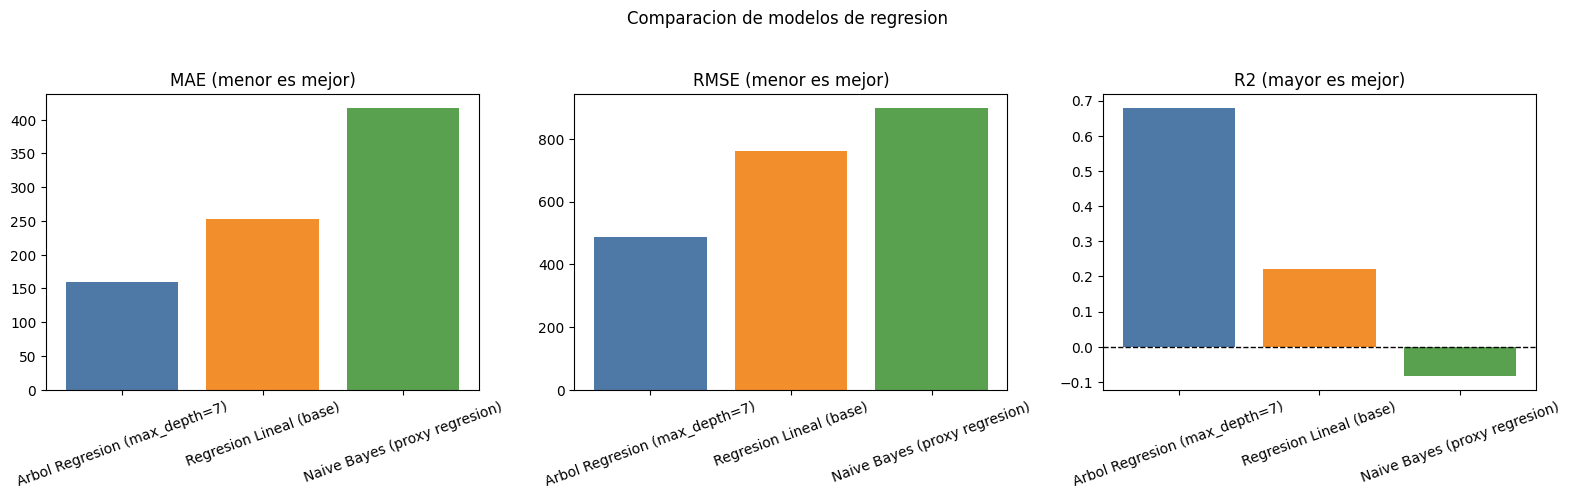

In [ ]:
# Grafica comparativa de metricas
import matplotlib.pyplot as plt

plot_df = comparison_models.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# MAE (menor es mejor)
axes[0].bar(plot_df['Modelo'], plot_df['MAE'], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[0].set_title('MAE (menor es mejor)')
axes[0].tick_params(axis='x', rotation=20)

# RMSE (menor es mejor)
axes[1].bar(plot_df['Modelo'], plot_df['RMSE'], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[1].set_title('RMSE (menor es mejor)')
axes[1].tick_params(axis='x', rotation=20)

# R2 (mayor es mejor)
axes[2].bar(plot_df['Modelo'], plot_df['R2'], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('R2 (mayor es mejor)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Comparacion de modelos de regresion', y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

### Conclusion de la Actividad 3

Con los resultados ejecutados, el ranking queda claro: **Arbol (`max_depth=7`) > Regresion Lineal > Naive Bayes**.

- **Arbol (`max_depth=7`)**: `MAE = 160.0926`, `RMSE = 487.6944`, `R2 = 0.6795`, `MedAE = 79.1202`, `MAPE = 68.8909%` (mejor desempeno global).
- **Regresion lineal**: `MAE = 252.8459`, `RMSE = 760.4884`, `R2 = 0.2206`, `MedAE = 128.2635`, `MAPE = 109.2552%` (intermedio).
- **Naive Bayes proxy**: `MAE = 416.7355`, `RMSE = 896.8748`, `R2 = -0.0841`, `MedAE = 261.0000`, `MAPE = 196.0260%` (peor).

El arbol gana porque captura mejor no linealidad e interacciones entre variables del mercado Airbnb. La lineal mejora frente a Naive Bayes, pero sigue limitada por supuestos lineales. Naive Bayes queda ultimo por discretizar un objetivo continuo y asumir independencia condicional, lo que incrementa errores y mantiene `R2` negativo.